### SARIMAX
AR(p): model uses its p past values <br>
I(d): differencing d times to remove the trend <br>
MA(q): model uses past forecast errors <br>
S(P, D, Q, s): seasonal lags <br>
X: exogenous variables

---
SARIMAX model for a sample client. Alternative approach is to cluster similar clients and fit one per cluster. 

### 1. Loading and preparing data
Selecting one random client. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random 

warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

# ── Same 30 clients as LR and Prophet notebooks ──
random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())
sampled_clients = random.sample(all_clients, 30)

# Pick first client for EDA (visualization, ACF/PACF, ADF)
sample_client = sampled_clients[0]

print(f"EDA on client {sample_client}, model will run on all {len(sampled_clients)}")
df_sample = df_long[df_long['ClientID'] == sample_client].copy()
df_sample = df_sample.set_index('Date')
df_sample.index = pd.to_datetime(df_sample.index)
df_sample = df_sample.sort_index()
df_sample = df_sample.asfreq("15min")

Loading processed data...
EDA on client MT_328, model will run on all 30


In [3]:
# y is the target variable, exog are the features we will use for modeling
y = df_sample['Consumption']
exog = df_sample[[
    'Weekday', 
    'Hour', 
    'Is_Weekend', 
    'Is_Holiday',
    'Temp_National_Avg', 
    'HDH', 
    'CDH',
    'Lag_15min', 
    'Lag_24h', 
    'Rolling_Mean_4h'
]].astype(float)

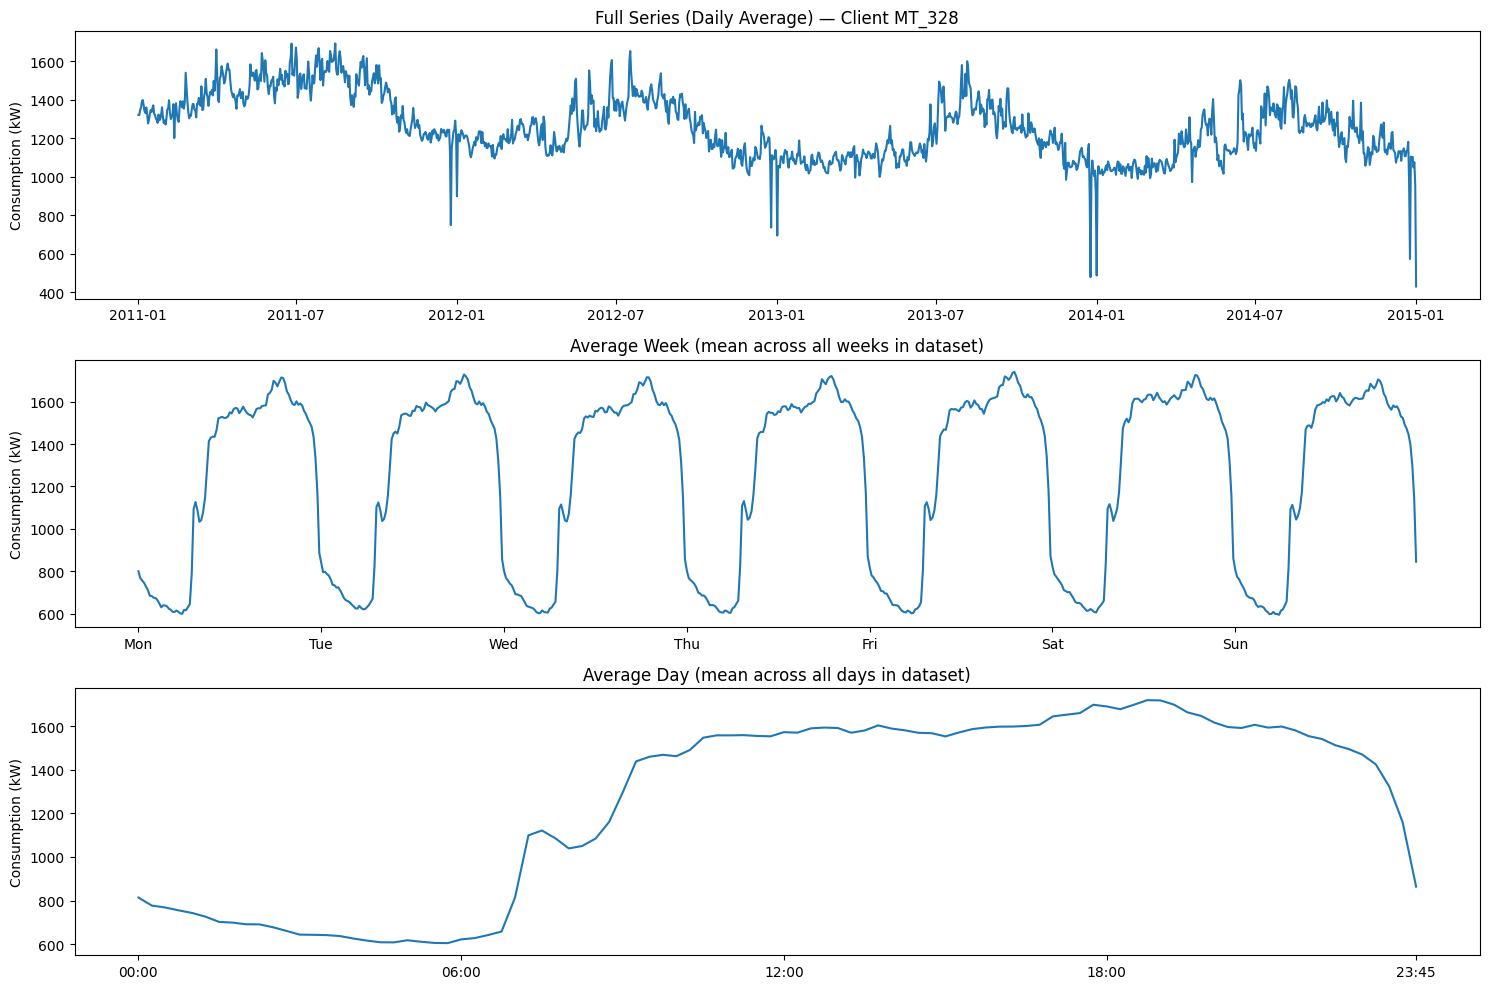

In [4]:
# Data vis for selected client
y_with_features = y.to_frame()
y_with_features['dayofweek'] = y.index.dayofweek
y_with_features['time_of_day'] = y.index.hour * 4 + y.index.minute // 15

average_week = y_with_features.groupby(['dayofweek', 'time_of_day'])['Consumption'].mean()
average_day  = y_with_features.groupby('time_of_day')['Consumption'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Full time series of daily average
axes[0].plot(y.resample('D').mean())
axes[0].set_title(f"Full Series (Daily Average) — Client {sample_client}")
axes[0].set_ylabel("Consumption (kW)")

# Average week
axes[1].plot(average_week.values)
axes[1].set_title("Average Week (mean across all weeks in dataset)")
axes[1].set_xticks([i * 96 for i in range(7)])
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel("Consumption (kW)")

# Average day
axes[2].plot(average_day.values)
axes[2].set_title("Average Day (mean across all days in dataset)")
axes[2].set_xticks([0, 24, 48, 72, 95])
axes[2].set_xticklabels(['00:00', '06:00', '12:00', '18:00', '23:45'])
axes[2].set_ylabel("Consumption (kW)")

plt.tight_layout()
plt.show()

### Seasonality 
In this section we decompose the time series into its trend, seasonal and residual components. Then we conduct an ADF test to see whether the mean drifts.
We can observe seasonality at the daily, weekly and yearly level.

We pick the most granular cycle which is the daily one s=96. 


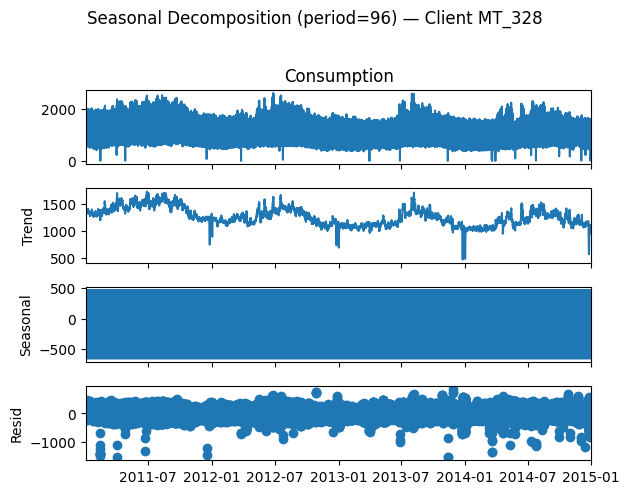

In [5]:
# Decompose into trend + seasonality + residual
# period=96: daily seasonality at 15-minute frequency (96 intervals per day)
decomposition = seasonal_decompose(y, model="additive", period=96)
decomposition.plot()
plt.suptitle(f"Seasonal Decomposition (period=96) — Client {sample_client}", y=1.02)
plt.tight_layout()
plt.show()

In the raw electricity consumption we can see the overall level stays fairly consistent across the 4 years with some sharp dips (outages?). 

The Trend subplot shows the long-term movement after removing daily seasonality patterns. Clearly we can still observe a yearly seasonal component in the data. 

In the seasonal plot, we can see the repeating daily cycle. The pattern is consistent throughout the 4 years.  

The residuals represent the remaining variation in the time series after account for the trend and the seasonal component. The bulk of the points show no discernible pattern and are clustered around 0, however we see that every 6 months there are a few large that are outliers in the data.

In [6]:
# The ADF test

def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n{'='*50}")
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("Stationary, no differencing needed (d=0)")
    else:
        print("Non-stationary — consider differencing (d=1)")

adf_test(df_sample['Consumption'], f"Electricity Consumption — Client {sample_client}")


ADF Test: Electricity Consumption — Client MT_328
  ADF Statistic : -19.5220
  p-value       : 0.0000
Stationary, no differencing needed (d=0)


### ACF and PACF plots
ACF plots shows the correlation with past values. 
The PACF plot shows the direct correltion with past values, removing the influence of intermediate lags. 
They help us manually select the SARIMAX model parameters. 

The ACF plot shows slow sinusoidal decay confirming the seasonal patterns we observed previously and indicating the MA component is weak or absent. There is no clean cutoff point to read q from.  

The PACF plot shows a very strong spike at lag 1, then drops immediately to near 0 for all other lags. Thus, we should choose AR p = 1 (after accounting for lag 1, no other past values add meaningful information).

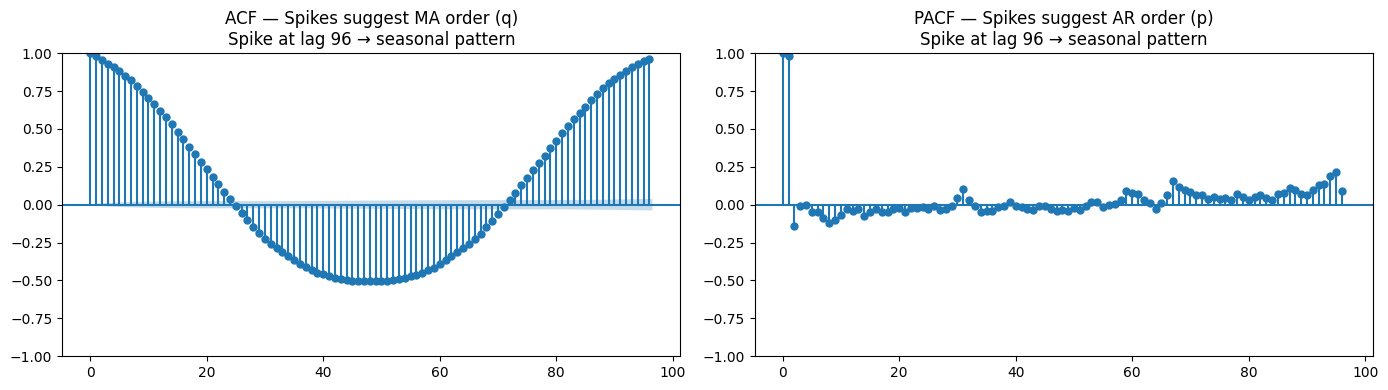

In [7]:
# Plotting ACF and PACF to identify AR and MA orders

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=96, ax=axes[0])  
axes[0].set_title("ACF — Spikes suggest MA order (q)\nSpike at lag 96 → seasonal pattern")

plot_pacf(y, lags=96, ax=axes[1])
axes[1].set_title("PACF — Spikes suggest AR order (p)\nSpike at lag 96 → seasonal pattern")

plt.tight_layout()
plt.show()

In [8]:
# Based on ACF/PACF analysis of sampled client
p, d, q    = 1, 0, 1
P, D, Q, s = 1, 0, 1, 96

print(f"Using SARIMAX({p},{d},{q})({P},{D},{Q},{s})")


Using SARIMAX(1,0,1)(1,0,1,96)


### Fitting the model
Parameter selction: 
Three approaches were considered for selecting the SARIMAX parameters (p, d, q, P, D, Q, s). The first approach involved running auto_arima on the full 15-minute resolution data, which was immediately infeasible due to memory errors caused by the large dataset size (~140,000 rows per client) combined with a seasonal period of s=96. 
The second approach involved downsampling to hourly data s=24 before running auto_arima, which reduced the dataset size but still resulted in memory errors and excessively long runtimes even on a 6-month subset. 
The third approach was adopted: parameters were selected manually by inspecting the ACF and PACF plots. 

Fitting the model across 30 clients:
SARIMAX(1,0,1)(1,0,1,96) was fitted independently on each of the 30 sampled clients (same sample as the LR and Prophet notebooks) using a 2-week training window (~1,344 rows per client). Lag features were excluded from the exogenous variables since SARIMAX captures autocorrelation internally through its AR and MA components. Only variables known in advance (time features and weather) were used as exogenous regressors, preventing data leakage during forecasting. The model produces a 24-hour recursive forecast (96 steps at 15-minute resolution) using a single forecast() call.

In [9]:
import warnings
warnings.filterwarnings("ignore")

FORECAST_HORIZON = 96
TRAIN_WEEKS = 2

exog_cols = ['Weekday', 'Hour', 'Is_Weekend', 'Is_Holiday',
             'Temp_National_Avg', 'HDH', 'CDH']

all_maes  = []
all_rmses = []
failed_clients = []
all_predictions = {}

for client_id in sampled_clients:
    print(f"Fitting client {client_id}...", end=" ", flush=True)
    
    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date')
    df_client.index = pd.to_datetime(df_client.index)
    df_client = df_client.sort_index()
    df_client = df_client.asfreq("15min")
    
    y_full = df_client['Consumption']
    
    test_start = len(y_full) - FORECAST_HORIZON
    train_start = test_start - (TRAIN_WEEKS * 7 * 96)
    
    if train_start < 0:
        print("SKIPPED")
        failed_clients.append(client_id)
        continue
    
    y_train = y_full.iloc[train_start:test_start]
    y_test  = y_full.iloc[test_start:]
    
    exog_full = df_client[exog_cols].astype(float)
    exog_train = exog_full.iloc[train_start:test_start]
    exog_test  = exog_full.iloc[test_start:]
    
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        result = model.fit(disp=False, maxiter=50)
        
        # Single call — SARIMAX forecast is already recursive internally
        y_pred = result.forecast(steps=FORECAST_HORIZON, exog=exog_test).values
        all_predictions[client_id] = y_pred  # Add this line after y_pred

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        all_maes.append(mae)
        all_rmses.append(rmse)
        print(f"MAE={mae:.2f}, RMSE={rmse:.2f}")
        
    except Exception as e:
        print(f"FAILED: {e}")
        failed_clients.append(client_id)

print(f"\n{'='*50}")
print(f"--- 30-CLIENT SARIMAX BENCHMARK RESULTS ---")
print(f"Clients fitted: {len(all_maes)}/{len(sampled_clients)}")
print(f"Average MAE:  {np.mean(all_maes):.4f} kW")
print(f"Average RMSE: {np.mean(all_rmses):.4f} kW")

Fitting client MT_328... MAE=169.89, RMSE=290.95
Fitting client MT_058... MAE=23.86, RMSE=31.68
Fitting client MT_013... MAE=17.20, RMSE=20.17
Fitting client MT_141... MAE=0.26, RMSE=0.35
Fitting client MT_126... MAE=18.52, RMSE=22.62
Fitting client MT_115... MAE=6.45, RMSE=8.26
Fitting client MT_072... MAE=12.57, RMSE=14.95
Fitting client MT_053... MAE=11.31, RMSE=16.63
Fitting client MT_347... MAE=0.17, RMSE=0.20
Fitting client MT_280... MAE=49.32, RMSE=64.41
Fitting client MT_045... MAE=37.51, RMSE=43.71
Fitting client MT_303... MAE=29.77, RMSE=37.37
Fitting client MT_217... MAE=37.28, RMSE=56.99
Fitting client MT_017... MAE=9.33, RMSE=11.32
Fitting client MT_016... MAE=15.60, RMSE=19.49
Fitting client MT_048... MAE=2.85, RMSE=3.36
Fitting client MT_112... MAE=6.88, RMSE=10.19
Fitting client MT_120... MAE=13.21, RMSE=15.29
Fitting client MT_259... MAE=14.37, RMSE=17.81
Fitting client MT_309... MAE=21.64, RMSE=25.97
Fitting client MT_014... MAE=4.87, RMSE=6.12
Fitting client MT_288..

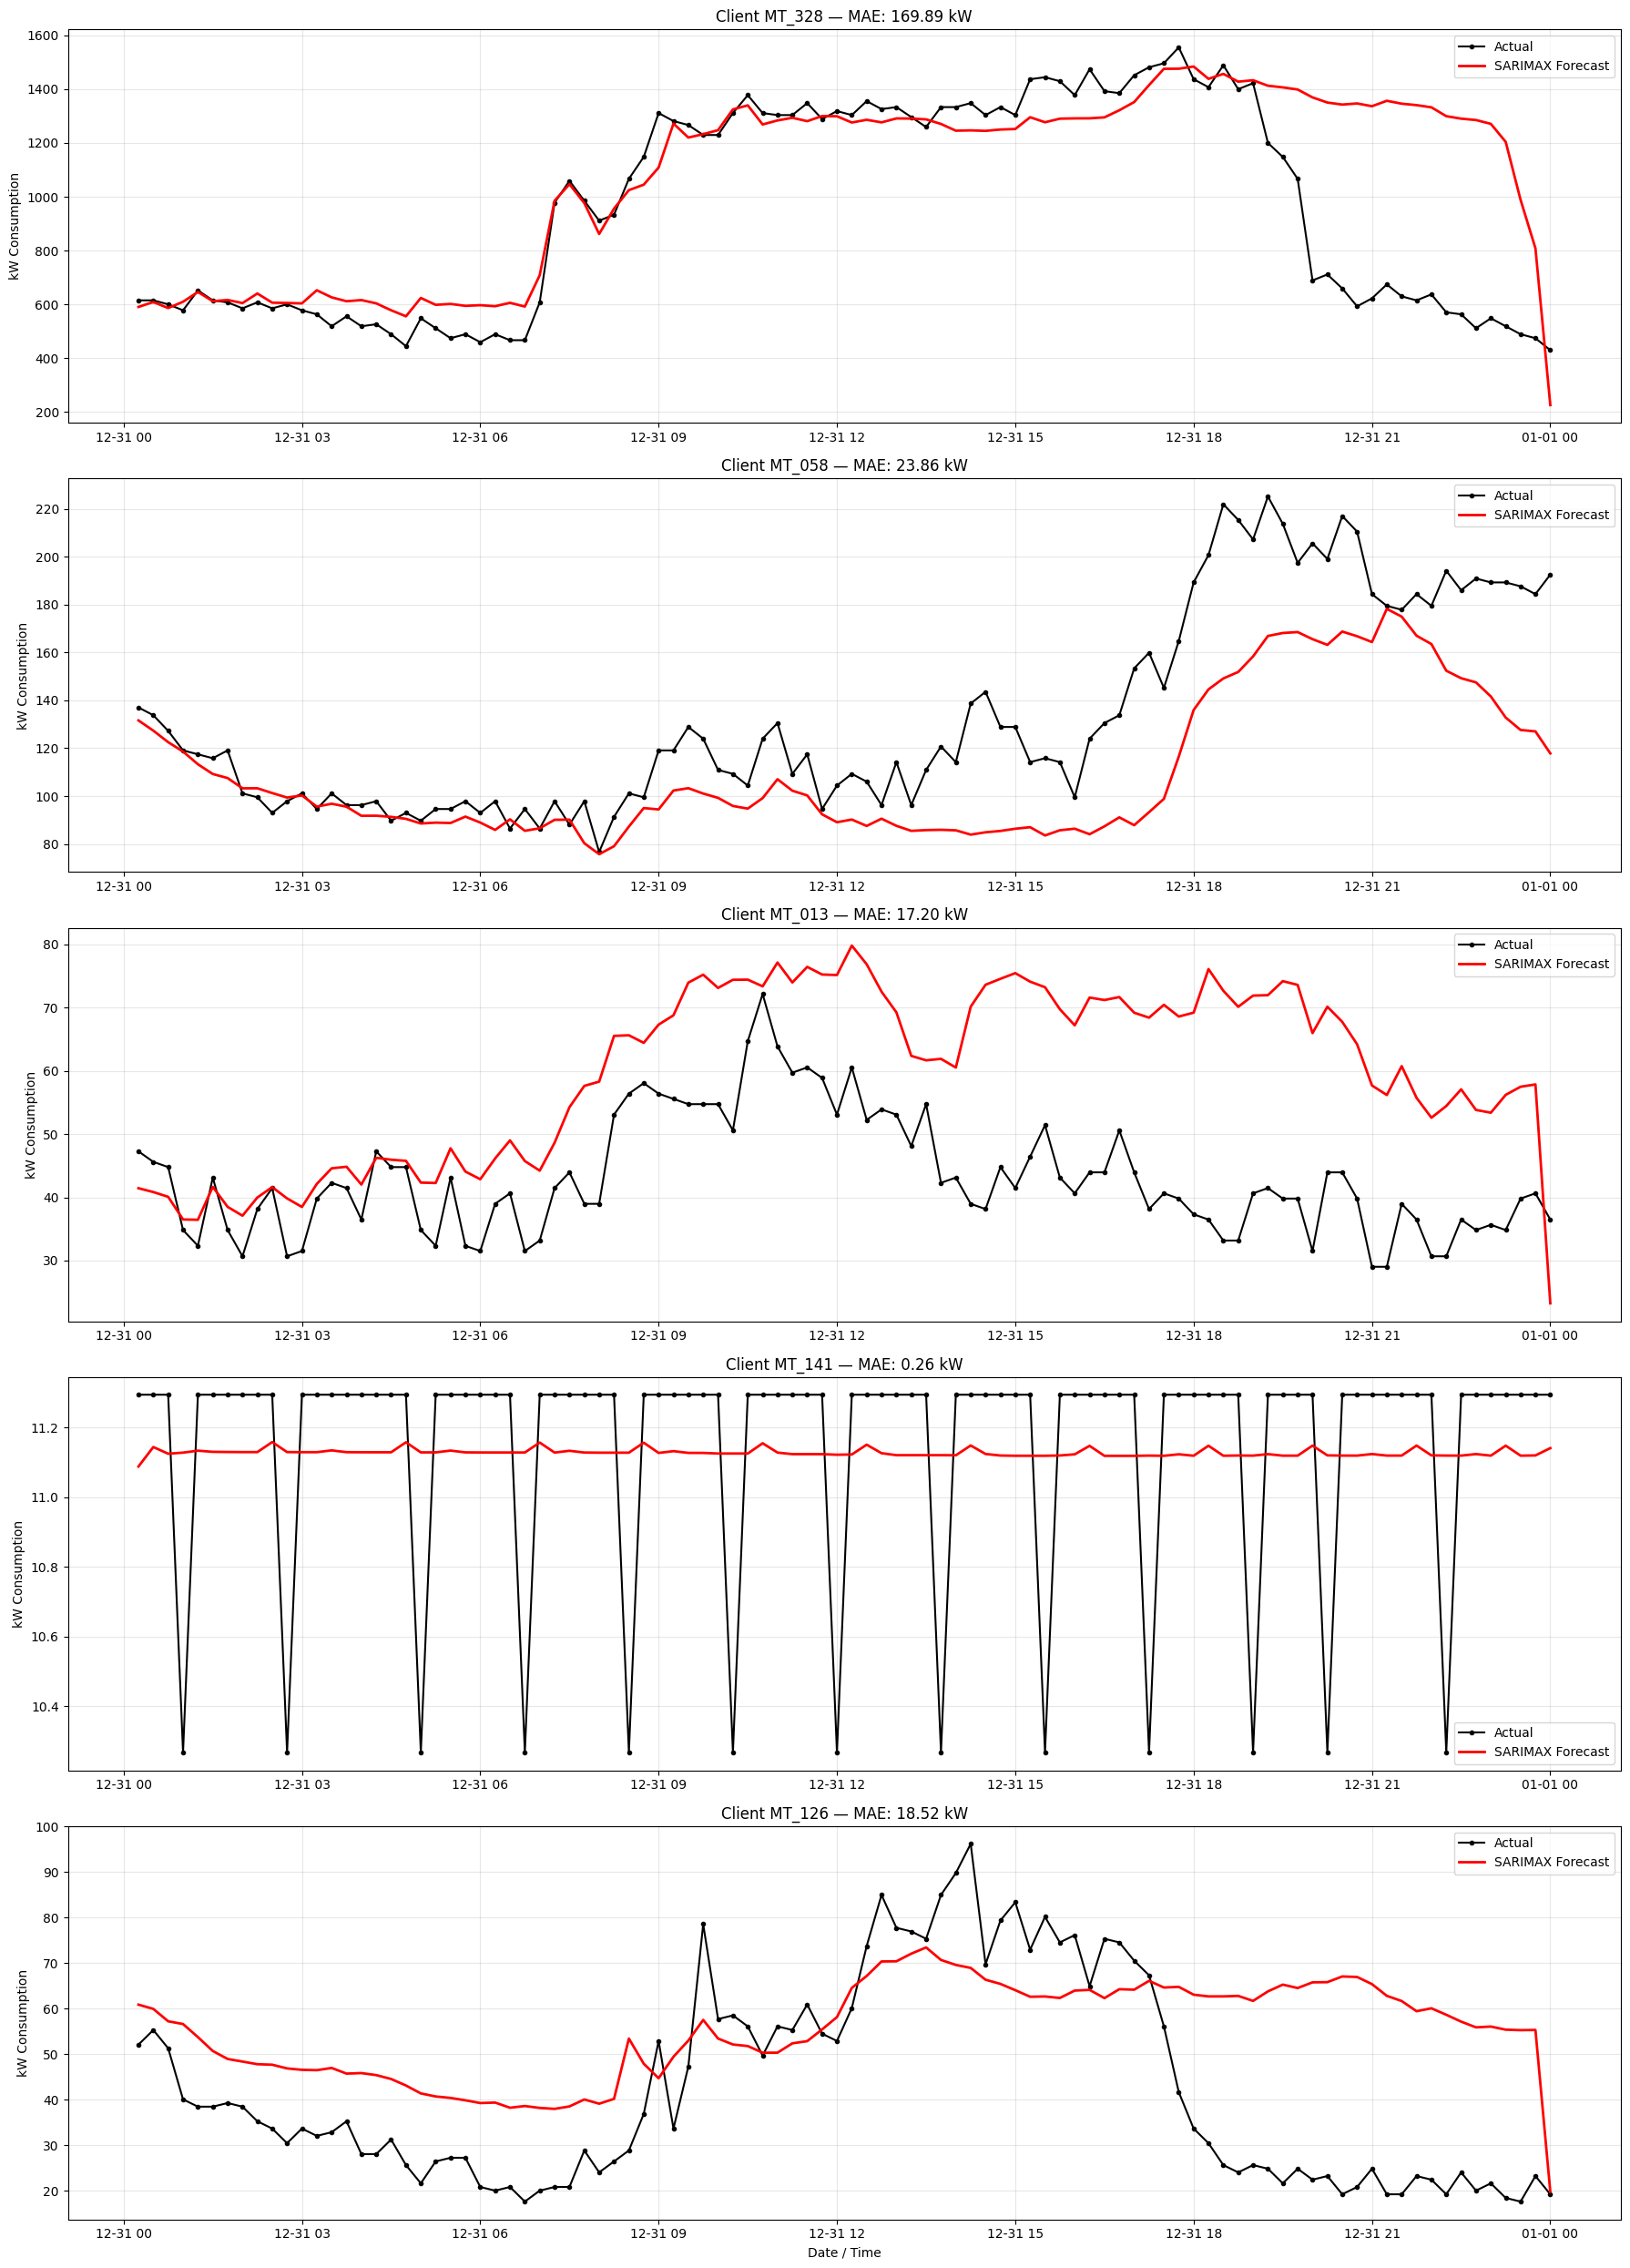

In [10]:
# ---------------------------------------------------------
# Visualization: Forecast vs Actuals for select clients
# ---------------------------------------------------------
vis_clients = [c for c in sampled_clients if c not in failed_clients][:5]

fig, axes = plt.subplots(len(vis_clients), 1, figsize=(18, 5 * len(vis_clients)))

for idx, client_id in enumerate(vis_clients):
    ax = axes[idx]
    
    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date')
    df_client.index = pd.to_datetime(df_client.index)
    df_client = df_client.sort_index()
    
    y_test = df_client['Consumption'].iloc[-FORECAST_HORIZON:]
    y_pred = all_predictions[client_id]
    
    mae = mean_absolute_error(y_test, y_pred)
    
    ax.plot(y_test.index, y_test.values, label='Actual', color='black', marker='.', linestyle='-')
    ax.plot(y_test.index, y_pred, label='SARIMAX Forecast', color='red', linewidth=2)
    ax.set_title(f"Client {client_id} — MAE: {mae:.2f} kW")
    ax.set_ylabel('kW Consumption')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date / Time')
plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# WMAPE per client (for fair cross-model comparison)
# ---------------------------------------------------------
all_wmapes = []

for client_id, y_pred in all_predictions.items():
    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date')
    df_client.index = pd.to_datetime(df_client.index)
    df_client = df_client.sort_index()
    
    y_test = df_client['Consumption'].iloc[-FORECAST_HORIZON:].values
    sum_actual = np.sum(y_test)
    if sum_actual > 0:
        all_wmapes.append(np.sum(np.abs(y_test - y_pred)) / sum_actual)

print(f"Average WMAPE: {np.mean(all_wmapes):.2%}")

Average WMAPE: 24.41%
